In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, mean_squared_error, accuracy_score


In [24]:
data = pd.read_csv('cleaned_telco_churn.csv')

In [4]:
df = pd.DataFrame(data)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29,29.85,...,0,0,0,0,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,56,1889.50,...,0,0,0,0,0,1,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,1,53,108.15,...,0,0,0,0,0,0,0,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,0,42,1840.75,...,1,0,0,0,0,1,0,0,0,0
4,9237-HQITU,0,0,0,0,2,1,1,70,151.65,...,0,0,0,0,0,0,0,0,1,0


In [6]:
df = df.drop('customerID', axis=1)

In [7]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   int64  
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleLines_Y

In [9]:
X=df.drop('Churn', axis=1)
y=df['Churn']

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [12]:
model = rf.fit(X_train, y_train)

In [13]:
prediction = model.predict(X_test)

In [16]:
print(prediction)

[0 0 1 ... 0 0 0]


In [17]:
print(y_test)

2476    0
6773    0
6116    1
3047    0
4092    0
       ..
1728    0
5241    0
5456    0
5842    0
3977    0
Name: Churn, Length: 1407, dtype: int64


In [18]:
accuracy = accuracy_score(prediction, y_test)

In [19]:
print(accuracy)

0.7874911158493249


In [20]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.45      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



C:\Users\pc\AppData\Local\Temp\ipykernel_2788\588363888.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importances, x='Importance', y='Feature', palette='viridis')


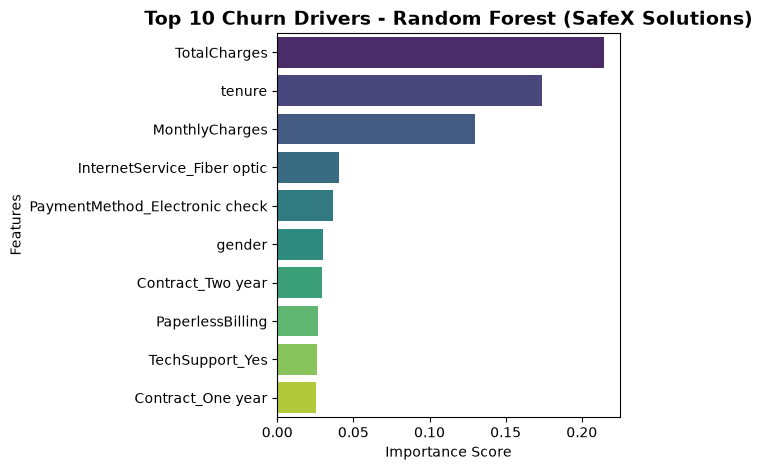

In [26]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Dataframe banana top 10 features ka
feat_importances = pd.DataFrame({
    'Feature': X.columns[indices][:10],
    'Importance': importances[indices][:10]
})
#plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Churn Drivers - Random Forest (SafeX Solutions)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


In [28]:

avg_monthly_charges = 65  
saved_customers = 150    

monthly_revenue_saved = saved_customers * avg_monthly_charges
annual_revenue_saved = monthly_revenue_saved * 12

print(f"--- SafeX Business Impact Frame ---")
print(f"Potential Monthly Revenue Saved: ${monthly_revenue_saved:,}")
print(f"Potential Annual Revenue Saved: ${annual_revenue_saved:,}")


--- SafeX Business Impact Frame ---
Potential Monthly Revenue Saved: $9,750
Potential Annual Revenue Saved: $117,000
